In [1]:
# Import libraries
import torch
import matplotlib.pyplot as plt
from bertopic import BERTopic
import pandas as pd
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [2]:
# Load model
model = BERTopic.load("../bertopic_model", embedding_model="sentence-transformers/all-MiniLM-L6-v2")

In [3]:
# Read data, remove stop words, and update topics, increasing the number of words per topic
df = pd.read_csv('../data/02-processed/reviews_sentiment.csv')
stop_words = set(stopwords.words("english"))
df['content'] = df['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
model.update_topics(df['content'], top_n_words=100)

In [4]:
# Grab topics and save them to a dictionary
dict = model.get_topics()
print(len(model.get_topics()))
print(dict)

7
{0: [('powercreep', np.float64(0.05584927797650522)), ('game', np.float64(0.05356859044703571)), ('characters', np.float64(0.045330444205622364)), ('character', np.float64(0.03737688174537779)), ('new', np.float64(0.03305366336294839)), ('hp', np.float64(0.030321632885773792)), ('story', np.float64(0.02993364558570832)), ('power', np.float64(0.02897011347927849)), ('the', np.float64(0.028742372654245264)), ('creep', np.float64(0.025031514765081028)), ('even', np.float64(0.02356043710870325)), ('inflation', np.float64(0.022855725066936557)), ('like', np.float64(0.022659147927497382)), ('much', np.float64(0.022425489096119557)), ('old', np.float64(0.021401177145436646)), ('hoyo', np.float64(0.019915259725038065)), ('hsr', np.float64(0.01969203580538341)), ('every', np.float64(0.019589032434899283)), ('global', np.float64(0.019364528571468517)), ('patch', np.float64(0.019056846279390673)), ('money', np.float64(0.01890222656935931)), ('content', np.float64(0.01868730342203748)), ('endgam

In [5]:
# Show topic info to user
model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,0,657,0_powercreep_game_characters_character,Power Creep,"[powercreep, game, characters, character, new,...",NaN
1,1,632,1_game_screen_update_phone,Optimization Feedback,"[game, screen, update, phone, play, fix, it, e...",NaN
2,2,617,2_game_gacha_characters_like,Gacha Feedback,"[game, gacha, characters, like, pity, star, ch...",NaN
3,3,369,3_collab_fate_game_trash,General Feedback,"[collab, fate, game, trash, bad, boring, worst...",NaN
4,4,353,4_error_login_account_log,Login Issues,"[error, login, account, log, game, please, can...",NaN
5,5,294,5_skip_story_button_game,Story/Dialogue,"[skip, story, button, game, add, dialogue, bor...",NaN
6,6,162,6_cyrene_buff_fix_kit,Cyrene Feedback,"[cyrene, buff, fix, kit, e2, her, character, e...",NaN


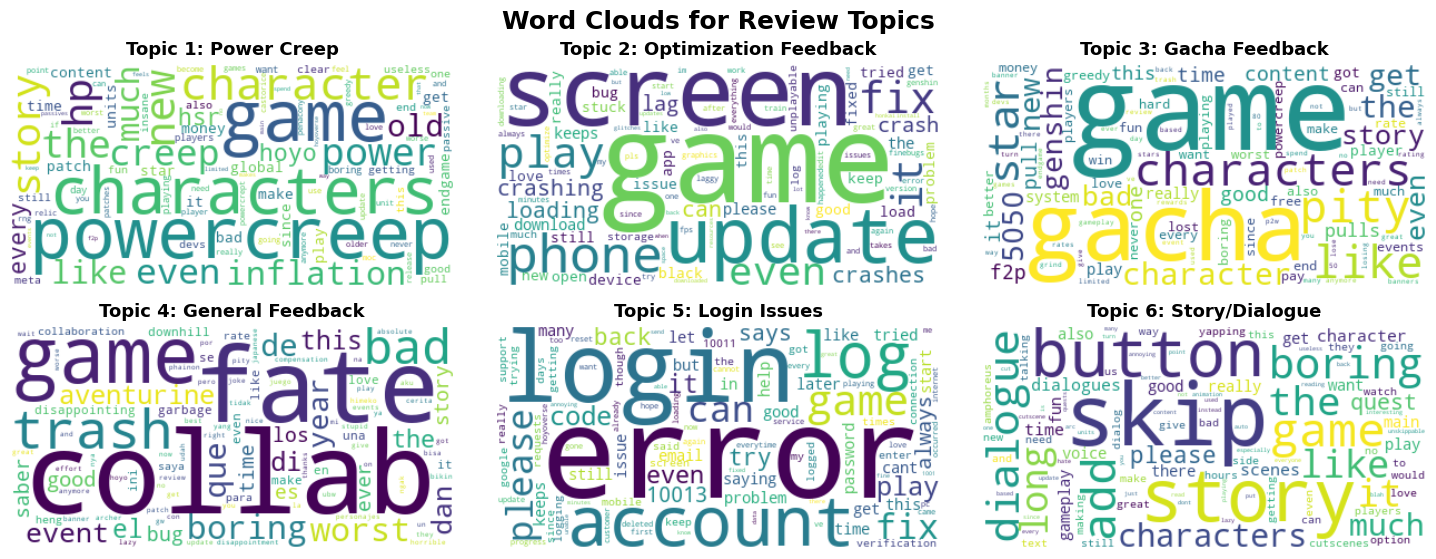

In [ ]:
# Function for making word cloud
def create_wordcloud(model, topic, ax1, ax2):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    axes[ax1, ax2].imshow(wc, interpolation="bilinear")
    axes[ax1, ax2].axis("off")
    axes[ax1, ax2].set_title(f'Topic {topic+1}: {model.get_topic_info()['CustomName'].iloc[topic]}', fontsize = 13, fontweight = 'bold', pad = 7)    

# Start from topic 0
topic_no = 0

# Make subplots for word clouds
fig, axes = plt.subplots(2, 3, figsize=(15,6))

# Create word clouds for each topic, where i represents the row and j the column
for i in range(2):
    for j in range(3):
        create_wordcloud(model, topic_no, i, j)
        topic_no+=1

# Adjust layout and show
plt.tight_layout(pad=3.0)
plt.suptitle('Word Clouds for Review Topics', fontsize = 18, fontweight = 'bold')
plt.subplots_adjust(top=0.90)
plt.savefig('../data/03-fig/wordcloud_reviews.png')
plt.show()